In [1]:
import os
import sys
sys.path.append("../")
device = "cuda"

In [2]:
import scanpy as sc
import squidpy as sq
import pandas as pd
from tqdm.notebook import tqdm
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl
import torch
import gc

from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = parti

In [3]:
import steamboat as sf

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib
plt.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['mathtext.fontset'] = 'dejavuserif'
matplotlib.rcParams['font.family'] = 'arial'

In [5]:
import warnings

In [6]:
adata = sq.read.visium("../../SEDR_analyses/data/BRCA1/V1_Human_Breast_Cancer_Block_A_Section_1")

c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\anndata\_core\anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\anndata\_core\anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [7]:
annotation = pd.read_csv("../../SEDR_analyses/data/BRCA1/metadata.tsv", sep="\t", index_col=0)
adata.obs = adata.obs.join(annotation)

In [8]:
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
adata.X = np.array(adata.X.todense())

In [9]:
adata.var['highly_variable'].sum()

np.int64(4741)

In [10]:
adata.X[:, adata.var['highly_variable'].tolist()]

array([[0.        , 0.        , 0.        , ..., 0.        , 1.0005606 ,
        2.5679176 ],
       [0.        , 0.32489273, 0.        , ..., 0.32489273, 0.9304022 ,
        1.7239419 ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.0590738 , 1.2560713 ,
        1.0590738 ],
       [0.        , 0.        , 0.        , ..., 0.7487769 , 0.7487769 ,
        1.46862   ],
       [0.        , 0.        , 0.        , ..., 1.8207632 , 2.2646358 ,
        2.9044518 ]], shape=(3798, 4741), dtype=float32)

In [11]:
adata.obs['global'] = 0
adatas = sf.prep_adatas([adata], n_neighs=6, norm=False, log1p=False, scale=False, renorm=False)
dataset = sf.make_dataset(adatas, sparse_graph=True, regional_obs=['global'], mask_var='highly_variable')

  0%|          | 0/1 [00:00<?, ?it/s]

Using ['global'] as regional annotations.


  0%|          | 0/1 [00:00<?, ?it/s]

Not all cells in the following samples have the same number of neighbors:
0.
Steamboat can handle this. You can safely ignore this warning if this is expected.


In [12]:
cuda_dataset = dataset.to('cuda')

In [ ]:
sf.set_random_seed(0)
model = sf.Steamboat(adatas[0].var_names[adatas[0].var['highly_variable']].tolist(), n_heads=20, n_scales=3)
model = model.to(device)
# model.fit(cuda_dataset, entry_masking_rate=0.1, feature_masking_rate=0.1,
#           max_epoch=10000, 
#           loss_fun=torch.nn.MSELoss(reduction='sum'),
#           opt=torch.optim.Adam, opt_args=dict(lr=0.01), stop_eps=1e-3, report_per=1000, stop_tol=200, device=device)

torch.save(model.state_dict(), 'saved_models/visium.pth')


[2026-05-17 22:54:01,834::train::INFO] Epoch 1: train_loss 1246.47009
[2026-05-17 22:54:07,342::train::INFO] Epoch 1001: train_loss 599.93884
[2026-05-17 22:54:12,727::train::INFO] Epoch 2001: train_loss 588.02606
[2026-05-17 22:54:18,015::train::INFO] Epoch 3001: train_loss 581.84174
[2026-05-17 22:54:23,343::train::INFO] Epoch 4001: train_loss 576.77502
[2026-05-17 22:54:28,604::train::INFO] Epoch 5001: train_loss 572.27618
[2026-05-17 22:54:33,867::train::INFO] Epoch 6001: train_loss 570.30090
[2026-05-17 22:54:39,139::train::INFO] Epoch 7001: train_loss 569.72449
[2026-05-17 22:54:44,410::train::INFO] Epoch 8001: train_loss 568.99103
[2026-05-17 22:54:45,327::train::INFO] Epoch 8176: train_loss 569.16351
[2026-05-17 22:54:45,328::train::INFO] Stopping criterion met.


In [14]:
import steamboat.tools
sf.tools.calc_obs(adatas, dataset, model, get_recon=True)
# sf.tools.gather_obs(adata, adatas)

  0%|          | 0/1 [00:00<?, ?it/s]

c:\Files\projects\Steamboat\revised\..\steamboat\tools.py:668: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  return sc.tl.leiden(adata, obsp=obsp, key_added=key_added, resolution=resolution, **leiden_kwargs)
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\squidpy\pl\_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\squidpy\pl\_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


NMI: 0.5996, ARI: 0.4756, n_clusters: 20


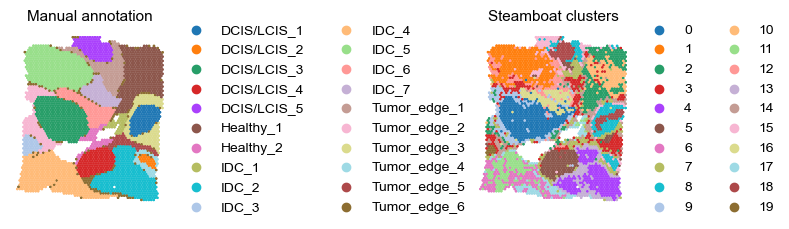

In [15]:
i = 0
sf.tools.neighbors(adatas[i], use_rep='attn')
sf.tools.leiden(adatas[i], resolution=1.3)
# adatas[i].uns.pop('steamboat_clusters_colors')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
sq.pl.spatial_scatter(adatas[i], color=["fine_annot_type", "steamboat_clusters"], shape=None, fig=fig, ax=axes, size=2.5, frameon=False)

labels_pred = adata.obs['steamboat_clusters'].values
labels_true = adata.obs['fine_annot_type'].values
nmi = normalized_mutual_info_score(labels_true, labels_pred)
ari = adjusted_rand_score(labels_true, labels_pred)

n_clusters = adata.obs['steamboat_clusters'].nunique()

print(f"NMI: {nmi:.4f}, ARI: {ari:.4f}, n_clusters: {n_clusters}")

axes[0].set_title("Manual annotation", fontsize=11)
axes[1].set_title("Steamboat clusters", fontsize=11)
fig.tight_layout(pad=2.)

In [19]:
adata.obsm['fine_annot_type_onehot'] = pd.get_dummies(adata.obs['fine_annot_type'])

In [20]:
adata.obsm['fine_annot_type_onehot']

,DCIS/LCIS_1,DCIS/LCIS_2,DCIS/LCIS_3,DCIS/LCIS_4,DCIS/LCIS_5,Healthy_1,Healthy_2,IDC_1,IDC_2,IDC_3,IDC_4,IDC_5,IDC_6,IDC_7,Tumor_edge_1,Tumor_edge_2,Tumor_edge_3,Tumor_edge_4,Tumor_edge_5,Tumor_edge_6
AAACAAGTATCTCCCA-1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
AAACACCAATAACTGC-1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
AAACAGAGCGACTCCT-1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
AAACAGGGTCTATATT-1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
AAACAGTGTTCCTGGG-1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
TTGTTTCACATCCAGG-1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
TTGTTTCATTAGTCTA-1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
TTGTTTCCATACAACT-1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [21]:
adata.obsm['neighbor_fine_annot_type_onehot'] = pd.DataFrame(adata.obsp['spatial_connectivities'].T @ adata.obsm['fine_annot_type_onehot'],
                                                             index=adata.obs_names, columns=adata.obsm['fine_annot_type_onehot'].columns)

In [22]:
adata.obs['Perturbation_study_label'] = 'Other' 
adata.obs.loc[(adata.obsm['neighbor_fine_annot_type_onehot']['IDC_3'] > 0) & 
              (adata.obsm["fine_annot_type_onehot"]["Tumor_edge_2"] > 0), 'Perturbation_study_label'] = 'Edge_near_IDC'
adata.obs.loc[(adata.obsm['neighbor_fine_annot_type_onehot']['IDC_4'] > 0) & 
              (adata.obsm["fine_annot_type_onehot"]["Tumor_edge_2"] > 0), 'Perturbation_study_label'] = 'Edge_near_IDC'
adata.obs.loc[(adata.obsm['neighbor_fine_annot_type_onehot']['IDC_5'] > 0) & 
              (adata.obsm["fine_annot_type_onehot"]["Tumor_edge_2"] > 0), 'Perturbation_study_label'] = 'Edge_near_IDC'
adata.obs.loc[(adata.obsm['neighbor_fine_annot_type_onehot']['IDC_6'] > 0) & 
              (adata.obsm["fine_annot_type_onehot"]["Tumor_edge_2"] > 0), 'Perturbation_study_label'] = 'Edge_near_IDC'

adata.obs.loc[(adata.obsm["neighbor_fine_annot_type_onehot"]["DCIS/LCIS_3"] > 0) & 
              (adata.obsm["fine_annot_type_onehot"]["Tumor_edge_2"] > 0), 'Perturbation_study_label'] = 'Edge_near_DCIS'

adata.obs['Perturbation_study_label'].value_counts()

Perturbation_study_label
Other             3748
Edge_near_DCIS      27
Edge_near_IDC       23
Name: count, dtype: int64

In [23]:
gt_adata = adata[:, adata.var['highly_variable']].copy()
# DEGs between Edge_near_IDC and Edge_near_DCIS
sc.tl.rank_genes_groups(gt_adata, groupby='Perturbation_study_label', groups=['Edge_near_IDC'], 
                        reference='Edge_near_DCIS', method='wilcoxon')
gt = sc.get.rank_genes_groups_df(gt_adata, group="Edge_near_IDC")
gt

,names,scores,logfoldchanges,pvals,pvals_adj
0,IGHA1,4.856577,1.897240,0.000001,0.005662
1,TCF4,3.377219,2.013786,0.000732,0.694298
2,MMP2,2.987914,1.156167,0.002809,1.000000
3,HTRA1,2.793262,1.104505,0.005218,1.000000
4,TTLL12,2.793262,0.844632,0.005218,1.000000
...,...,...,...,...,...
4736,HSPA6,-3.250695,-2.883725,0.001151,0.755732
4737,PSMB9,-3.250695,-1.351151,0.001151,0.755732
4738,CFB,-3.377219,-0.764914,0.000732,0.694298
4739,IFT122,-4.097433,-1.486574,0.000042,0.066020


In [24]:
adatas = sf.prep_adatas([gt_adata], n_neighs=6, norm=False, log1p=False, scale=False, renorm=False)
dataset = sf.make_dataset(adatas, sparse_graph=True, regional_obs=['global'], mask_var='highly_variable')
sf.tools.calc_obs(adatas, dataset, model, get_recon=True)

new_adata_0 = gt_adata[gt_adata.obs['Perturbation_study_label'].isin(['Edge_near_DCIS'])].copy()
new_adata_0.X = new_adata_0.obsm['X_recon']

perturb_adata = gt_adata.copy()
perturb_adata.X[gt_adata.obs['Perturbation_study_label'] == 'Edge_near_IDC'] = perturb_adata.X[gt_adata.obs['Perturbation_study_label'] == 'Edge_near_DCIS'][:23]

adatas = sf.prep_adatas([perturb_adata], n_neighs=6, norm=False, log1p=False, scale=False, renorm=False)
dataset = sf.make_dataset(adatas, sparse_graph=True, regional_obs=['global'], mask_var='highly_variable')
sf.tools.calc_obs(adatas, dataset, model, get_recon=True)

new_adata_1 = perturb_adata[perturb_adata.obs['Perturbation_study_label'].isin(['Edge_near_IDC'])].copy()
new_adata_1.X = new_adata_1.obsm['X_recon']

new_adata = sc.AnnData.concatenate(new_adata_0, new_adata_1)

# DEGs between Edge_near_IDC and Edge_near_DCIS
sc.tl.rank_genes_groups(new_adata, groupby='Perturbation_study_label', groups=['Edge_near_IDC'], reference='Edge_near_DCIS', method='wilcoxon')
pred = sc.get.rank_genes_groups_df(new_adata, group="Edge_near_IDC")
pred

  0%|          | 0/1 [00:00<?, ?it/s]

Using ['global'] as regional annotations.


  0%|          | 0/1 [00:00<?, ?it/s]

Not all cells in the following samples have the same number of neighbors:
0.
Steamboat can handle this. You can safely ignore this warning if this is expected.


  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

Not all cells in the following samples have the same number of neighbors:
0.
Steamboat can handle this. You can safely ignore this warning if this is expected.


  0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\lshh\AppData\Local\Temp\ipykernel_26308\575405856.py:18: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  new_adata = sc.AnnData.concatenate(new_adata_0, new_adata_1)


,names,scores,logfoldchanges,pvals,pvals_adj
0,AK9,2.014652,0.057486,0.043941,0.760309
1,AL627171.2,1.508556,0.067248,0.131412,0.992235
2,AC027279.1,1.430695,0.092627,0.152518,0.992235
3,PAXIP1-AS2,1.430695,0.028824,0.152518,0.992235
4,AC096921.2,1.352834,0.043503,0.176109,0.992235
...,...,...,...,...,...
4736,FCGR3B,-3.104706,-0.249005,0.001905,0.523516
4737,MAPK8IP1,-3.163101,-0.126828,0.001561,0.523516
4738,LINC02224,-3.163101,-0.256246,0.001561,0.523516
4739,SLC4A10,-3.202032,-0.168058,0.001365,0.523516


SignificanceResult(statistic=np.float64(0.22665228010264743), pvalue=np.float64(6.722695795407152e-37))

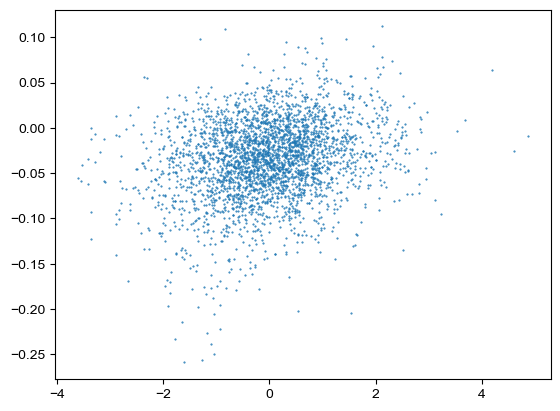

In [ ]:
# valid_genes = # gt['names'][(gt['pvals'] < 0.5)]
valid_genes = gt['names'][(gt['logfoldchanges'].abs() < 10) & (gt['pvals'] < 1.)]
gt = gt[gt['names'].isin(valid_genes)]
pred = pred.loc[pred['names'].isin(valid_genes)]
plt.plot(gt.sort_values('names')['logfoldchanges'], pred.sort_values('names')['logfoldchanges'], '.', ms=1)
s, p = sp.stats.spearmanr(gt.sort_values('names')['logfoldchanges'], pred.sort_values('names')['logfoldchanges'])
plt.title(f"Spearman correlation: {s:.3f}, p-value: {p:.3e}")